In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from neuroaging.utils.utils import compute_poststrat_weights

2025-07-08 20:52:21.489 | INFO     | neuroaging.config:<module>:11 - PROJ_ROOT path is: /home/groot/Projects/neuroaging


(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

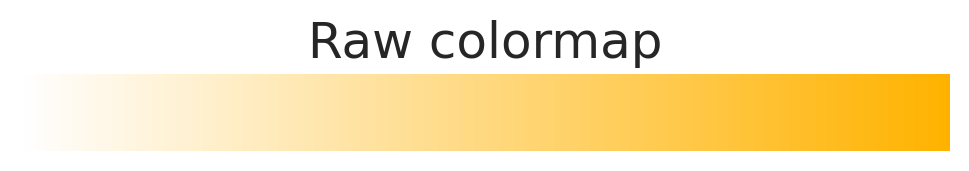

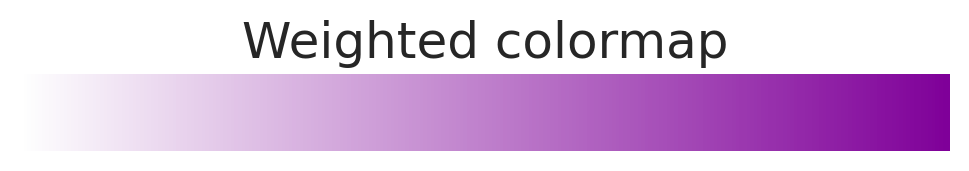

In [2]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "sans-serif",
        "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)


# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list(
    "raw", [COL_WHITE, COL_RAW_RGB], N=256
)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [3]:
# Tell the pipeline which side of the parabola is “structural stabilisation”
orientation = {  # feel free to expand
    "gm_vol": "min",  # concave-down expected
    "adc": "max",  # concave-up expected
    # "fa"   : "min",
    # "rd"   : "min",
}


def vertex_age(beta1, beta2):
    """Age at vertex of a quadratic   β0 + β1·x + β2·x²."""
    return -beta1 / (2 * beta2)


def stabilisation_age(metric, betas, pvalues, *, age_min=18, age_max=85,orientation=orientation):
    """
    betas = dict with keys "age" (β1) and "age_sq" (β2)
    Returns (age*, flagged)   where flagged=True if outside range or wrong shape.
    """
    want = orientation.get(metric, "min")  # default = 'min' if not listed
    β1, β2 = betas["age"], betas["age_sq"]
    p1, p2 = pvalues["age"], pvalues["age_sq"]
    # ── 1. Shape check  ────────────────────────────────────────────────
    if (p2 > 0.05) or (want == "min" and β2 <= 0):
        # parabola opens down – no minimum inside; flag & push to boundary
        return age_min, True
    elif (p2 > 0.05) or (want == "max" and β2 >= 0):
        # parabola opens up – no maximum inside
        return age_max, True

    # ── 2. Compute vertex  ─────────────────────────────────────────────
    age_star = vertex_age(β1, β2)
    clipped = False

    # clip to observed age window
    if age_star < age_min:
        age_star, clipped = age_min, True
    elif age_star > age_max:
        age_star, clipped = age_max, True

    return age_star, clipped

In [4]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/home/groot/Projects/neuroaging/data")

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [5]:
metric = "gm_vol"
metrics = [metric]
distribution_metric = "qfmean"

# Output directory for figures
OUTPUT_DIR = Path("/home/groot/Projects/neuroaging/figures/fig7") / ATLAS / metric
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

bad_subjects = ["IN120120"]

# Load the data
data = {}
for metric in metrics:
    data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
        drop=True
    )
    # drop problematic subjects
    data[metric] = data[metric][~data[metric]["subject_code"].isin(bad_subjects)]
    data[metric]["sex"] = data[metric]["sex"].map({"M": 0, "F": 1})


# data["age_squared"] = data["age_at_scan"] ** 2

/tmp/ipykernel_2930256/832649149.py:14: DtypeWarning: Columns (1,7) have mixed types. Specify dtype option on import or set low_memory=False.
  data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(


In [6]:
metric_cols = {
    metric: "volume" if metric == "gm_vol" else distribution_metric for metric in metrics
}

for m, df in data.items():
    df = df.rename(columns={metric_cols[m]: "value"})
    data[m] = df

In [7]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [8]:
# assign weights
for metric in metrics:
    data[metric]["subject_code"] = data[metric]["subject_code"].astype(str).str.zfill(4)

In [9]:
df = data[metrics[0]].drop_duplicates(subset=["subject_code"], keep="first").copy()

In [10]:
import pandas as pd


def group_by_age(df, age_col: str = "age_at_scan", n_bins: int = 50):
    """
    Group participants by age into n_bins with equal number of participants.

    Parameters:
    - df: DataFrame containing the data
    - age_col: Column name for age
    - n_bins: Number of bins to create

    Returns:
    - DataFrame with an additional column for age groups
    """
    # Create age groups with equal number of participants
    df["age_group"] = pd.qcut(df[age_col], q=n_bins, labels=False)

    # Optional: Assign labels like "Q1", "Q2", etc.
    df["age_group_label"] = pd.qcut(
        df[age_col], q=n_bins, labels=[f"Q{i+1}" for i in range(n_bins)]
    )
    # Group by the age_group_label column
    group_stats = df.groupby("age_group_label")["age_at_scan"].agg(
        median_age="median", mean_age="mean", sd_age="std", n_participants="count"
    )

    # Merge stats back into original df
    return df.merge(group_stats, on="age_group_label", how="left")

In [11]:
# use sm.ols
import statsmodels.api as sm
import statsmodels.formula.api as smf

scns = {}
for metric in metrics:
    long_df = data[metric].copy()
    ages = group_by_age(
        long_df.drop_duplicates(subset="subject_code", keep="first"),
        age_col="age_at_scan",
        n_bins=50,
    )
    age_group_map = ages[["subject_code", "age_group_label", "age_at_scan"]]
    covariates = ["sex"] if metric != "gm_vol" else ["sex", "tiv"]

    # if metric == "gm_vol":
    #     long_df["value"] = long_df["value"] / long_df["tiv"]
    # correct for sex
    wide_df = long_df.pivot_table(index="subject_code", columns=[region_col], values="value")
    # residualise for sex, and if needed, for TIV
    for col in wide_df.columns:
        df_tmp = ages.set_index("subject_code").copy()
        df_tmp["value"] = wide_df[col]
        model = smf.ols("value ~ " + " + ".join(covariates), data=df_tmp).fit()
        wide_df[col] = model.resid + model.params["Intercept"]
        # break
    # break

    # Step 2: Add age group info to wide matrix
    for group_name, group_df in ages.groupby("age_group_label"):
        # Create a new column for each age group
        region_matrix = wide_df.loc[group_df["subject_code"]]
        corr_matrix = region_matrix.corr(method="spearman")
        scns[group_name] = {"corr_matrix": corr_matrix, "metadata": group_df}

    # wide_df = wide_df.merge(age_group_map, left_on="subject_code", right_on="subject_code")
    # wide_df = wide_df.merge(age_group_map, left_on="subject_code", right_on="subject_code")
    # break

/tmp/ipykernel_2930256/942385700.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_group"] = pd.qcut(df[age_col], q=n_bins, labels=False)
/tmp/ipykernel_2930256/942385700.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_group_label"] = pd.qcut(
/tmp/ipykernel_2930256/942385700.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future de

In [12]:
OUTPUT_DIR

PosixPath('/home/groot/Projects/neuroaging/figures/fig7/schaefer2018tian2020_400_7/gm_vol')

In [13]:
import bct
from tqdm import tqdm
import networkx as nx

network_matrices_dict = {}

FORCE = False

NETWORK_METRICS_DIR = Path(str(OUTPUT_DIR).replace("fig7","fig5"))

metrics_directory = NETWORK_METRICS_DIR / "network_matrices"
metrics_directory.mkdir(parents=True, exist_ok=True)

for group_name, group_data in tqdm(scns.items(), desc="Calculating network matrices"):
    target_file = metrics_directory / f"{group_name}.csv"
    if not FORCE and target_file.exists():
        print(f"Loading existing file: {target_file}")
        p = pd.read_csv(target_file, index_col=0)
        network_matrices_dict[group_name] = p
        continue
    # break

network_matrices = pd.concat(network_matrices_dict.values(), ignore_index=True)

Calculating network matrices: 100%|██████████| 50/50 [00:00<00:00, 621.68it/s]

Loading existing file: /home/groot/Projects/neuroaging/figures/fig5/schaefer2018tian2020_400_7/gm_vol/network_matrices/Q1.csv
Loading existing file: /home/groot/Projects/neuroaging/figures/fig5/schaefer2018tian2020_400_7/gm_vol/network_matrices/Q2.csv
Loading existing file: /home/groot/Projects/neuroaging/figures/fig5/schaefer2018tian2020_400_7/gm_vol/network_matrices/Q3.csv
Loading existing file: /home/groot/Projects/neuroaging/figures/fig5/schaefer2018tian2020_400_7/gm_vol/network_matrices/Q4.csv
Loading existing file: /home/groot/Projects/neuroaging/figures/fig5/schaefer2018tian2020_400_7/gm_vol/network_matrices/Q5.csv
Loading existing file: /home/groot/Projects/neuroaging/figures/fig5/schaefer2018tian2020_400_7/gm_vol/network_matrices/Q6.csv
Loading existing file: /home/groot/Projects/neuroaging/figures/fig5/schaefer2018tian2020_400_7/gm_vol/network_matrices/Q7.csv
Loading existing file: /home/groot/Projects/neuroaging/figures/fig5/schaefer2018tian2020_400_7/gm_vol/network_matrices

In [14]:
network_matrices["index"] = parcels["index"].values.tolist() * len(
    network_matrices["group"].unique()
)

In [15]:
network_matrices["weight"], _ = compute_poststrat_weights(
    network_matrices,
    israel_population,
    age_col="median_age",
    cap=None,  # try None first; if still spiky, use 4 or 5
    return_bin_table=True,
)

In [43]:
from notebooks.fig5.calculate_network_measures import NETWORK_MEASURES


key = "degree"
wide_network_metrics = network_matrices.pivot_table(index="group", columns=[region_col], values=key)
meta_conn = wide_network_metrics.corr(method="spearman").values
meta_conn_inverse = 1 / meta_conn
np.fill_diagonal(meta_conn, 0)  # Set diagonal to zero
np.fill_diagonal(meta_conn_inverse, 0)  # Set diagonal to zero
# estimate network metrics for the meta-connectome

# network_matrices

/tmp/ipykernel_2930256/2240006283.py:7: RuntimeWarning: divide by zero encountered in divide
  meta_conn_inverse = 1 / meta_conn


In [44]:
meta_parcels = parcels.copy()
for measure in NETWORK_MEASURES:
    func = measure["func"]
    outputs = measure["outputs"]
    results = (
        func(meta_conn)
        if "betweenness" not in outputs
        else func(
            meta_conn_inverse,
        )
    )  # handle betweenness separately
    if len(outputs) == 1:
        results = [results]
    for col, res in zip(outputs, results):
        meta_parcels[col] = res

In [45]:
# network_matrices.loc[network_matrices[region_col] == y + 1]

Text(0, 0.5, 'index 447 (degree)')

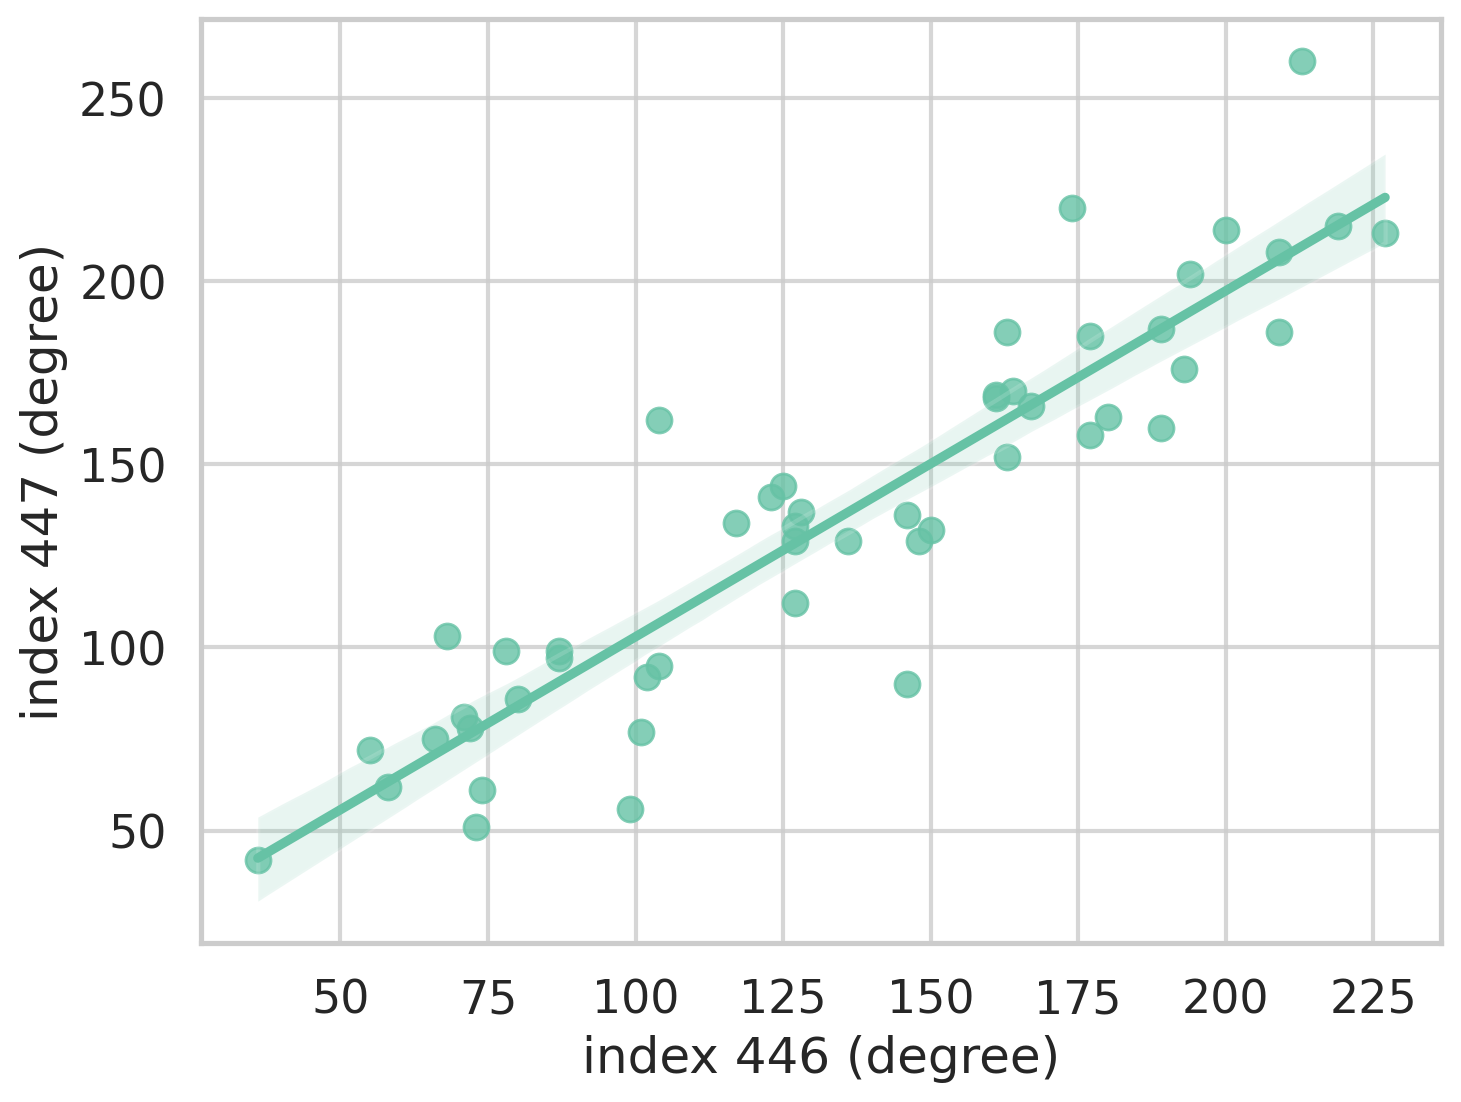

In [46]:
# get the x and y coordinates of the strongest connection in meta_conn
x, y = np.unravel_index(np.argmax(meta_conn, axis=None), meta_conn.shape)

# Plot for demonstration
fig, ax = plt.subplots(figsize=(8, 6))
x_vals = network_matrices.loc[network_matrices[region_col] == x+1, "degree"]
y_vals = network_matrices.loc[network_matrices[region_col] == y + 1, "degree"]
sns.regplot(x=x_vals, y=y_vals, ax=ax)
ax.set_xlabel(f"{region_col} {x+1} ({key})")
ax.set_ylabel(f"{region_col} {y+1} ({key})")

In [83]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

vis_df = meta_parcels.copy()
value_map_lh = {}  # New: separate map for left hemisphere
value_map_rh = {}  # New: separate map for right hemisphere

key = "betweenness"  # or "strength", "degree", etc.
value_threshold = vis_df[key].quantile(0.5)  # Set threshold to 5th percentile

for i, row in vis_df.iterrows():
    label = row[region_col]
    hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

    # Apply thresholds
    value = row[key]
    value = value if value >= value_threshold else np.nan
    # value = float(vis_df.loc[i, "color_tag"]) + 1

    # Populate the correct hemisphere's value_map
    # Assuming your labels are global and you use the 'hemisphere' column to distinguish
    # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
    # then you might only need to check the label range and not the 'hemisphere' column.
    # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
    if "schaefer" in ATLAS:
        if label > int(ATLAS.split("_")[1]):
            value_map_subcortex["region"].append(label)
            value_map_subcortex["value"].append(value)
            value_map_subcortex["Hemisphere"].append(row["hemisphere"])
        else:
            if hemi_row == "L":
                value_map_lh[label] = value
            elif hemi_row == "R":
                value_map_rh[label] = value
        # Subcortex handling would go here if you were preparing for separate subcortical visualization
        # else: # This implies it's subcortical or other non-surface region
        #     value_map_subcortex["region"].append(label)
        #     value_map_subcortex["value"].append(value)
        #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

# Vectorize mapping for left and right hemispheres separately
vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation

In [84]:
vis_df[vis_df["network"] == "subcortex"].sort_values(by=key, ascending=False).head(20)

,index,name,base_name,Label Name,network,component,hemisphere,degree,strength,betweenness,global_efficiency
448,449,mAMY-lh,mAMY,"Amygdala, medial nucleus",subcortex,Amygdala,L,223.0,0.642886,182351.0,-0.000007
422,423,THA-DP-rh,THA-DP,"Thalamus, dorso-posterior part",subcortex,Thalamus,R,222.0,3.287859,181574.0,-0.000007
420,421,lAMY-rh,lAMY,"Amygdala, lateral nucleus",subcortex,Amygdala,R,214.0,-4.471070,179203.0,-0.000007
411,412,THA-DAl-rh,THA-DAl,"Thalamus, lateral dorso-anterior part",subcortex,Thalamus,R,194.0,-2.376382,178759.0,-0.000007
445,446,CAU-body-lh,CAU-body,Caudate body,subcortex,Caudate body,L,188.0,-5.184326,175141.0,-0.000007
401,402,HIP-head-m2-rh,HIP-head-m2,"Hippocampus head, medial division",subcortex,Hippocampus head,R,198.0,-3.394859,163354.0,-0.000007
428,429,HIP-head-m2-lh,HIP-head-m2,"Hippocampus head, medial division",subcortex,Hippocampus head,L,225.0,0.084218,155249.0,-0.000007
427,428,HIP-head-m1-lh,HIP-head-m1,"Hippocampus head, medial division",subcortex,Hippocampus head,L,210.0,-0.545665,140276.0,-0.000007
443,444,CAU-VA-lh,CAU-VA,"Caudate, ventro-anterior part",subcortex,Caudate,L,197.0,-5.342201,135242.0,-0.000007
449,450,THA-DP-lh,THA-DP,"Thalamus, dorso-posterior part",subcortex,Thalamus,L,216.0,2.811321,134295.0,-0.000007


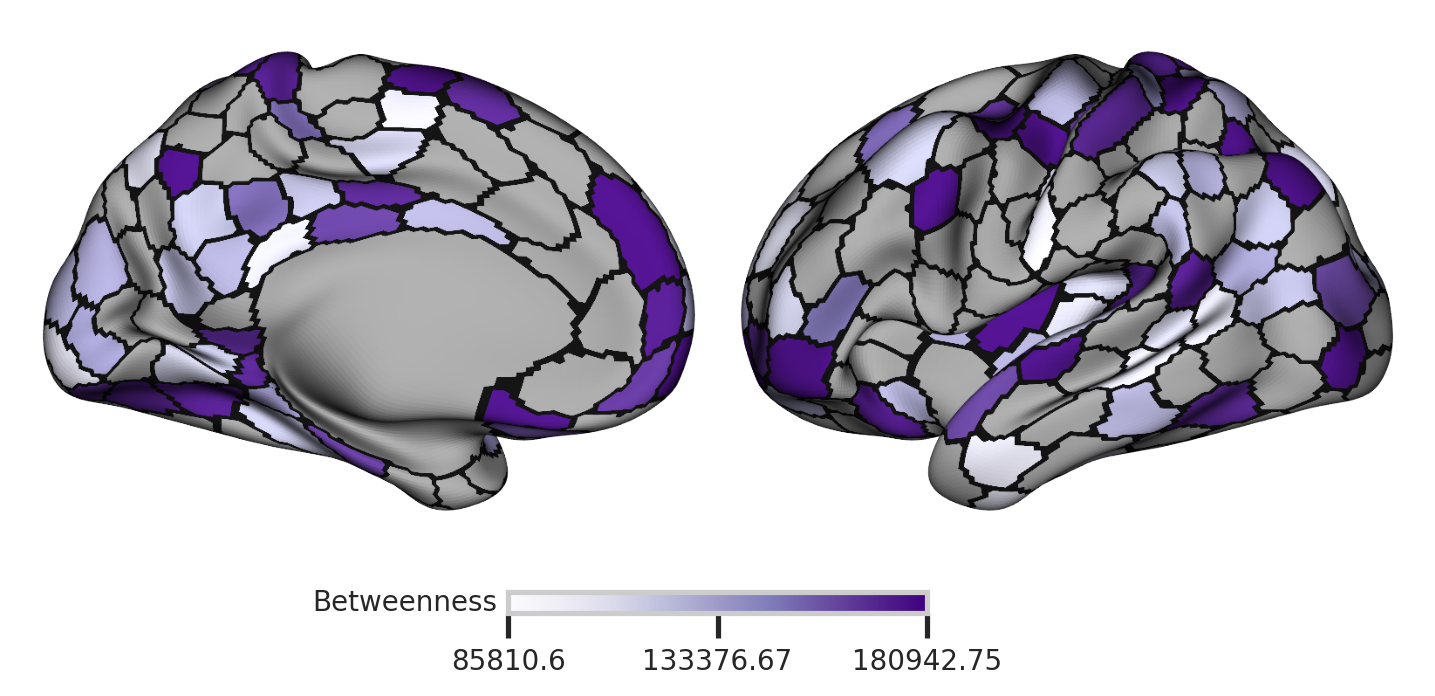

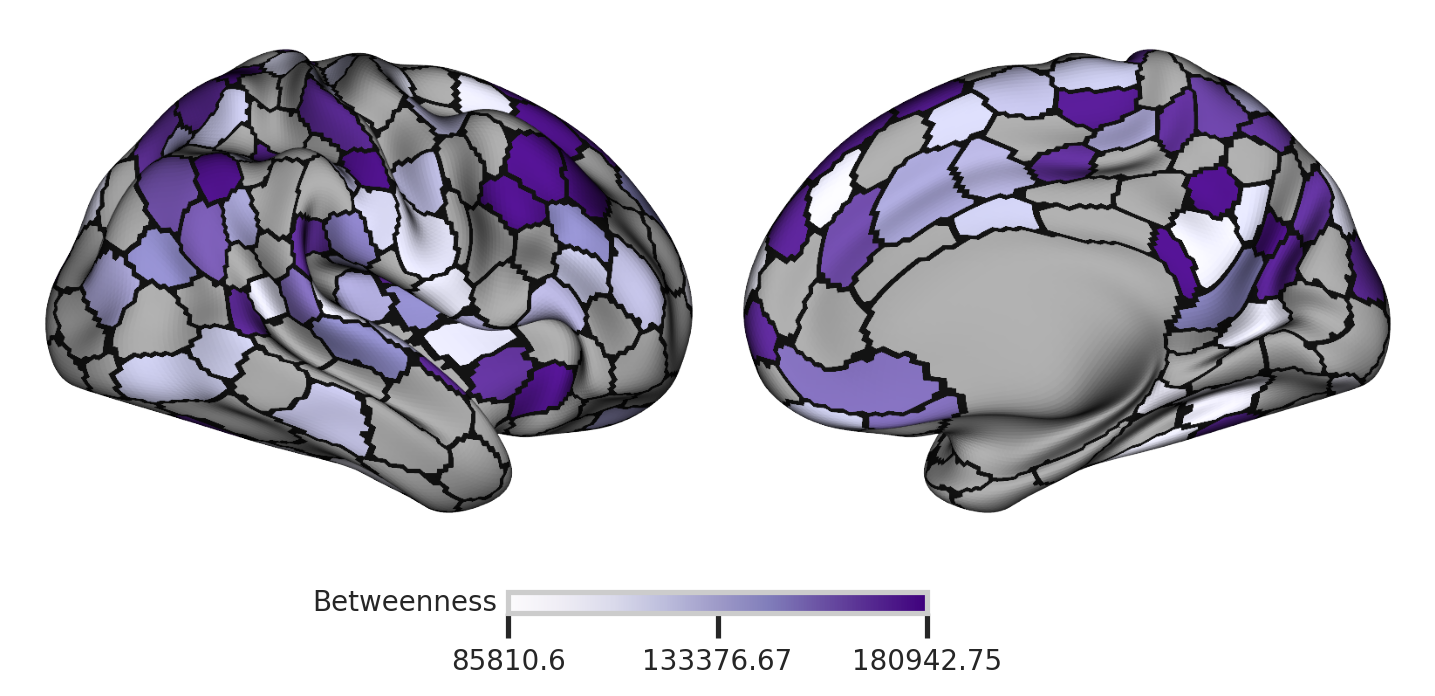

In [89]:
# vmin = vis_df[key].quantile(0.4)
vmin = vis_df[key].quantile(0.4)  # Set a lower bound for the color range
vmax = vis_df[key].quantile(0.95)  # Set an upper bound for the color range


# Corrected loop for plotting each hemisphere independently
for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
    ["left", "right"],  # The key for surfplot's dictionary
    [lh, rh],  # The surface object for the current hemisphere
    [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
    [lh_parc, rh_parc],  # The parcellation for the current hemisphere
):
    # ---------------------------------------------------------------------
    # 5.  BUILD THE PLOT
    # ---------------------------------------------------------------------
    pref_surf = {
        "surf_lh": hemi_surf_data if hemi_key == "left" else None,
        "surf_rh": hemi_surf_data if hemi_key == "right" else None,
    }

    views = ["lateral", "medial"] if hemi_key == "right" else ["medial", "lateral"]

    p = Plot(
        **pref_surf,  # Unpack the surface dictionary
        views=views,  # Show both medial and lateral for this hemi
        size=(800, 300),  # px; change as needed
        zoom=1.6,
        layout="row",  # For a single hemisphere, row is fine
        mirror_views=False,  # Set to False, as we are plotting one hemi at a time
    )

    # ---- main data layer -------------------------------------------------
    # Pass only the data for the current hemisphere
    # The dictionary now contains only one key-value pair for the current hemisphere
    p.add_layer(
        {hemi_key: mapped_data},
        cmap="Purples",
        color_range=(vmin, vmax),  # Use symmetric range
        # norm=norm,  # Apply the symmetric normalization
        cbar_label=key.capitalize(),
        cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
    )
    # ---- outline layer ---------------------------------------------------
    p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

    fig = p.build(
        # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
    )  # Added cbar_kws for better cbar display
    # savefig_nice(
    #     fig,
    #     OUTPUT_DIR / f"{hemi_key}_yeo_7_networks.png",
    #     tight=True,
    #     dpi=300,
    # )

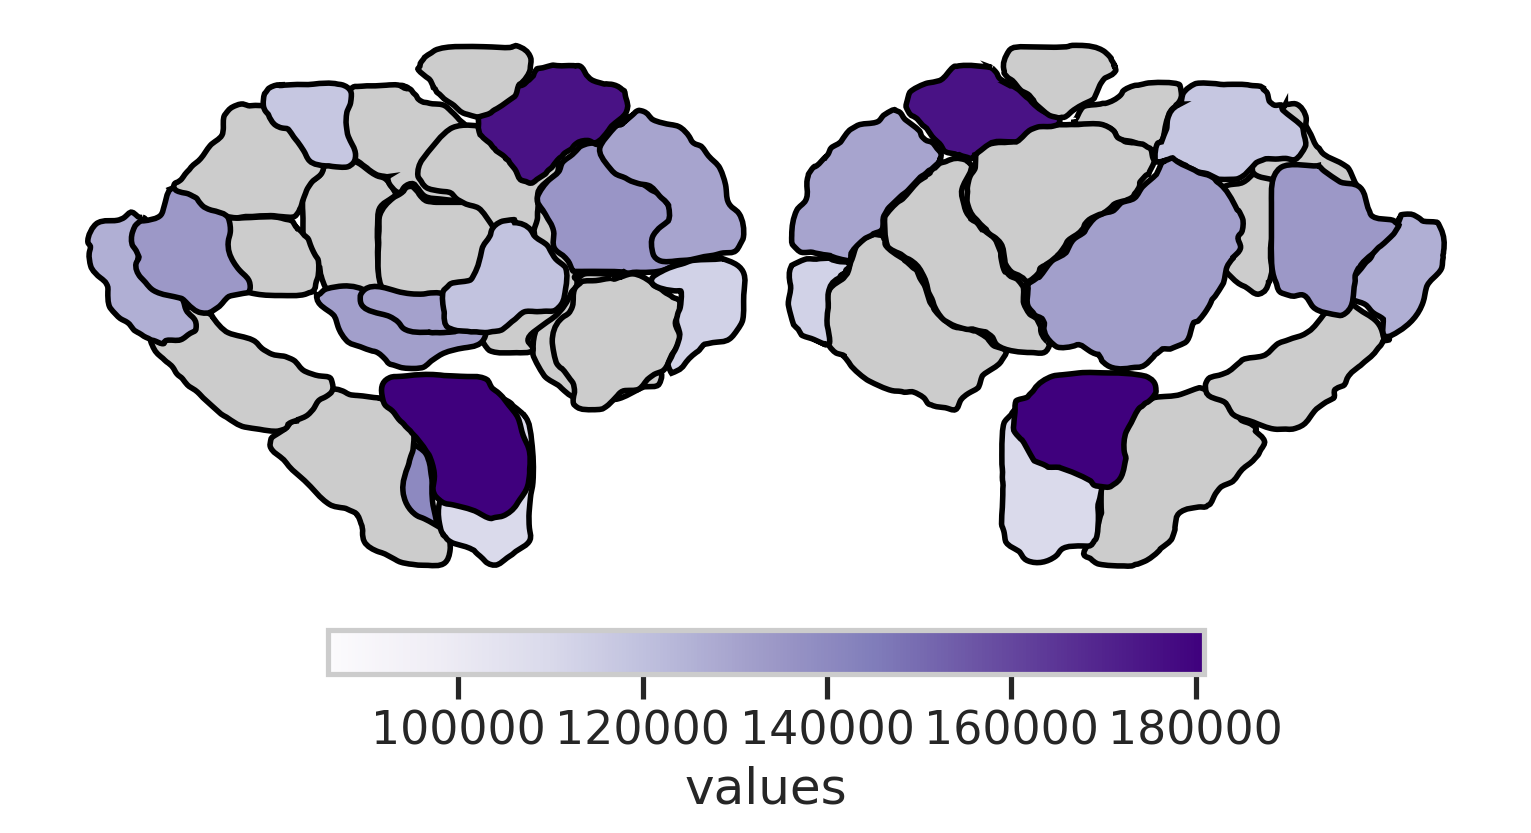

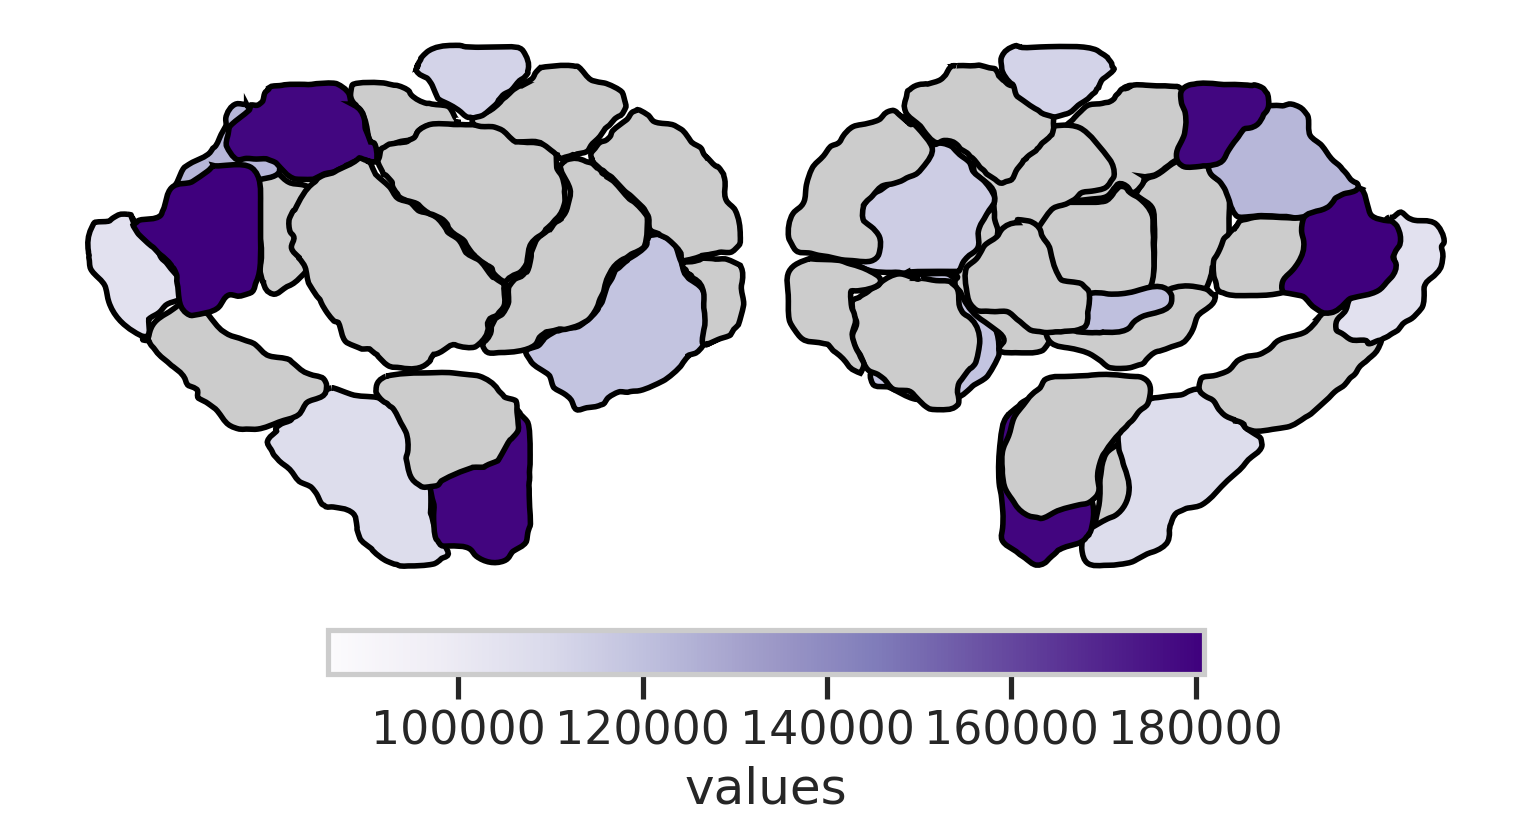

In [90]:
from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])

# subcort_df["value"] = 7
for hemi in ["L", "R"]:

    fig = plot_subcortical_data(
        subcort_df,
        atlas="Melbourne_S3",
        show_legend=True,
        hemisphere=hemi,
        cmap="Purples",
        line_color="black",
        line_thickness=2,
        vmin=vmin,
        vmax=vmax,
        show_figure=False,
    )

    # save figure
    # savefig_nice(
    #     fig,
    #     OUTPUT_DIR / f"subcortical_{hemi}_yeo_subcortex.png",
    #     tight=True,
    #     dpi=300,
    # )
    # savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mne.viz import circular_layout

from mne_connectivity.viz import plot_connectivity_circle


mat = meta_conn
network_col = "network"  # or "network" if you want to use the network column

threshold = 0.4

# zero diagonal
np.fill_diagonal(mat, 0)
# Threshold the connectivity matrix
masked_matrix = np.where(np.abs(mat) < threshold, np.nan, mat)
masked_matrix = pd.DataFrame(masked_matrix, index=parcels[region_col], columns=parcels[region_col])


parcels_vis = parcels.copy()

# sort parcels by hemi and network (make one hemi a mirror image of the other)
hemi_l = parcels_vis[parcels_vis["hemisphere"] == "L"].sort_values(by=network_col)
hemi_r = parcels_vis[parcels_vis["hemisphere"] == "R"].sort_values(by=network_col).iloc[::-1]
parcels_vis = pd.concat([hemi_l, hemi_r], ignore_index=True)

# automatically set unique colors for each network
# "network" is a columns with strings like "Visual", "Somatomotor", etc.


node_angles = circular_layout(
    parcels_vis[region_col].tolist(),
    node_order=parcels_vis[region_col].tolist(),
    # start_pos=-68,
    # group_boundaries=parcels_vis["network"].astype("category").cat.codes.tolist(),
    # group_colors=parcels_vis["color"].tolist(),
)

node_grouping = parcels_vis[network_col].astype("category").cat.codes.tolist()
group_labels = parcels_vis[network_col].unique().tolist()

masked_matrix = masked_matrix[parcels_vis[region_col]].loc[parcels_vis[region_col]].values

In [80]:
import matplotlib.colors as mpl_colors  # for ListedColormap and BoundaryNorm


# --- UNIFIED COLOR MAPPING SETUP (APPLY THIS ONCE GLOBALLY) ---
# Assuming 'communities' DataFrame has the final 'community_id' column
# Make sure community_id is an integer, starting from 0.
unique_community_ids = sorted(parcels_vis[network_col].unique())
num_communities = len(unique_community_ids)

# Generate a palette (e.g., 'tab10' has 10 colors, good if you have <=10 communities)
# If you have more, use 'tab20', 'Spectral', or define a custom list.
palette_colors = sns.color_palette("Set2", n_colors=num_communities)

# Create a consistent mapping from community_id (integer) to actual RGB color tuple
community_id_to_rgb_map = dict(zip(unique_community_ids, palette_colors))

# Create the ListedColormap and BoundaryNorm for the surface plot
# The bounds should define ranges for each integer community ID
bounds = np.arange(num_communities + 1)
cmap_communities = mpl_colors.ListedColormap(
    [community_id_to_rgb_map[cid] for cid in unique_community_ids]
)
norm_communities = mpl_colors.BoundaryNorm(bounds, cmap_communities.N)

# --- Add a 'color_rgb' column to your DataFrame for the circular plot ---
# This column will directly hold the RGB tuples for each region based on its community ID
parcels_vis[f"{network_col}_color_rgb"] = parcels_vis[network_col].map(community_id_to_rgb_map)

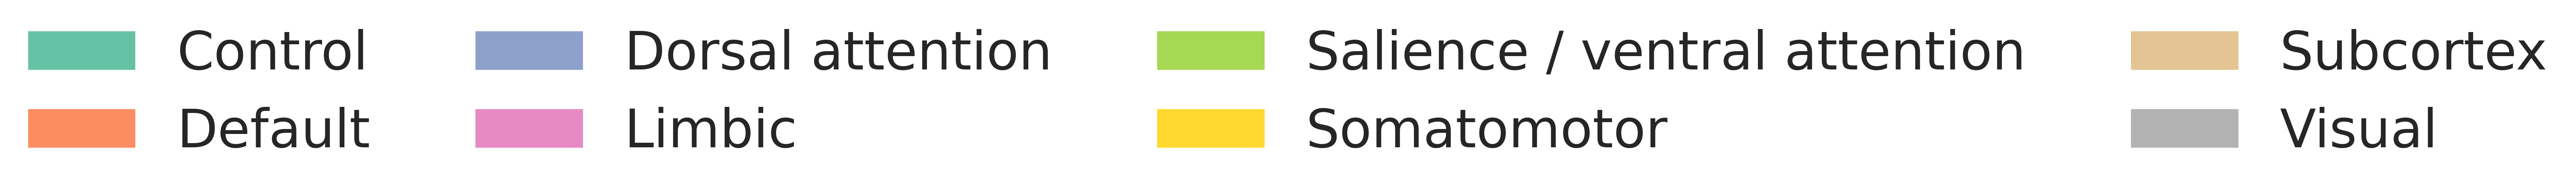

In [81]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# This script assumes 'colors_mapping' exists from the previous step
# colors_mapping = {'Visual': (r,g,b), 'Somatomotor': (r,g,b), ...}

# --- 1. Create a new figure just for the legend ---
# Adjust figsize to your needs. (width, height)
fig_legend, ax_legend = plt.subplots(figsize=(2, 2.5))

# --- 2. Create proxy artists (handles) for the legend ---
legend_handles = [
    mpatches.Patch(color=color, label=network.capitalize())
    for network, color in community_id_to_rgb_map.items()
]

# --- 3. Add the legend to the new figure's axes ---
ax_legend.legend(
    handles=legend_handles,
    # title="Network",
    loc="center",  # Center the legend in the figure
    fontsize=50,
    title_fontsize="x-large",
    frameon=False,  # Optional: remove the frame around the legend
    ncol=4,
)

# --- 4. Turn off the axes to make the background transparent ---
ax_legend.axis("off")

# --- 5. Show and save the legend figure ---
# Use bbox_inches='tight' to remove extra white space
# Use transparent=True for a transparent background when saving
# fig_legend.savefig('network_legend.png', bbox_inches='tight', transparent=True)

plt.show()

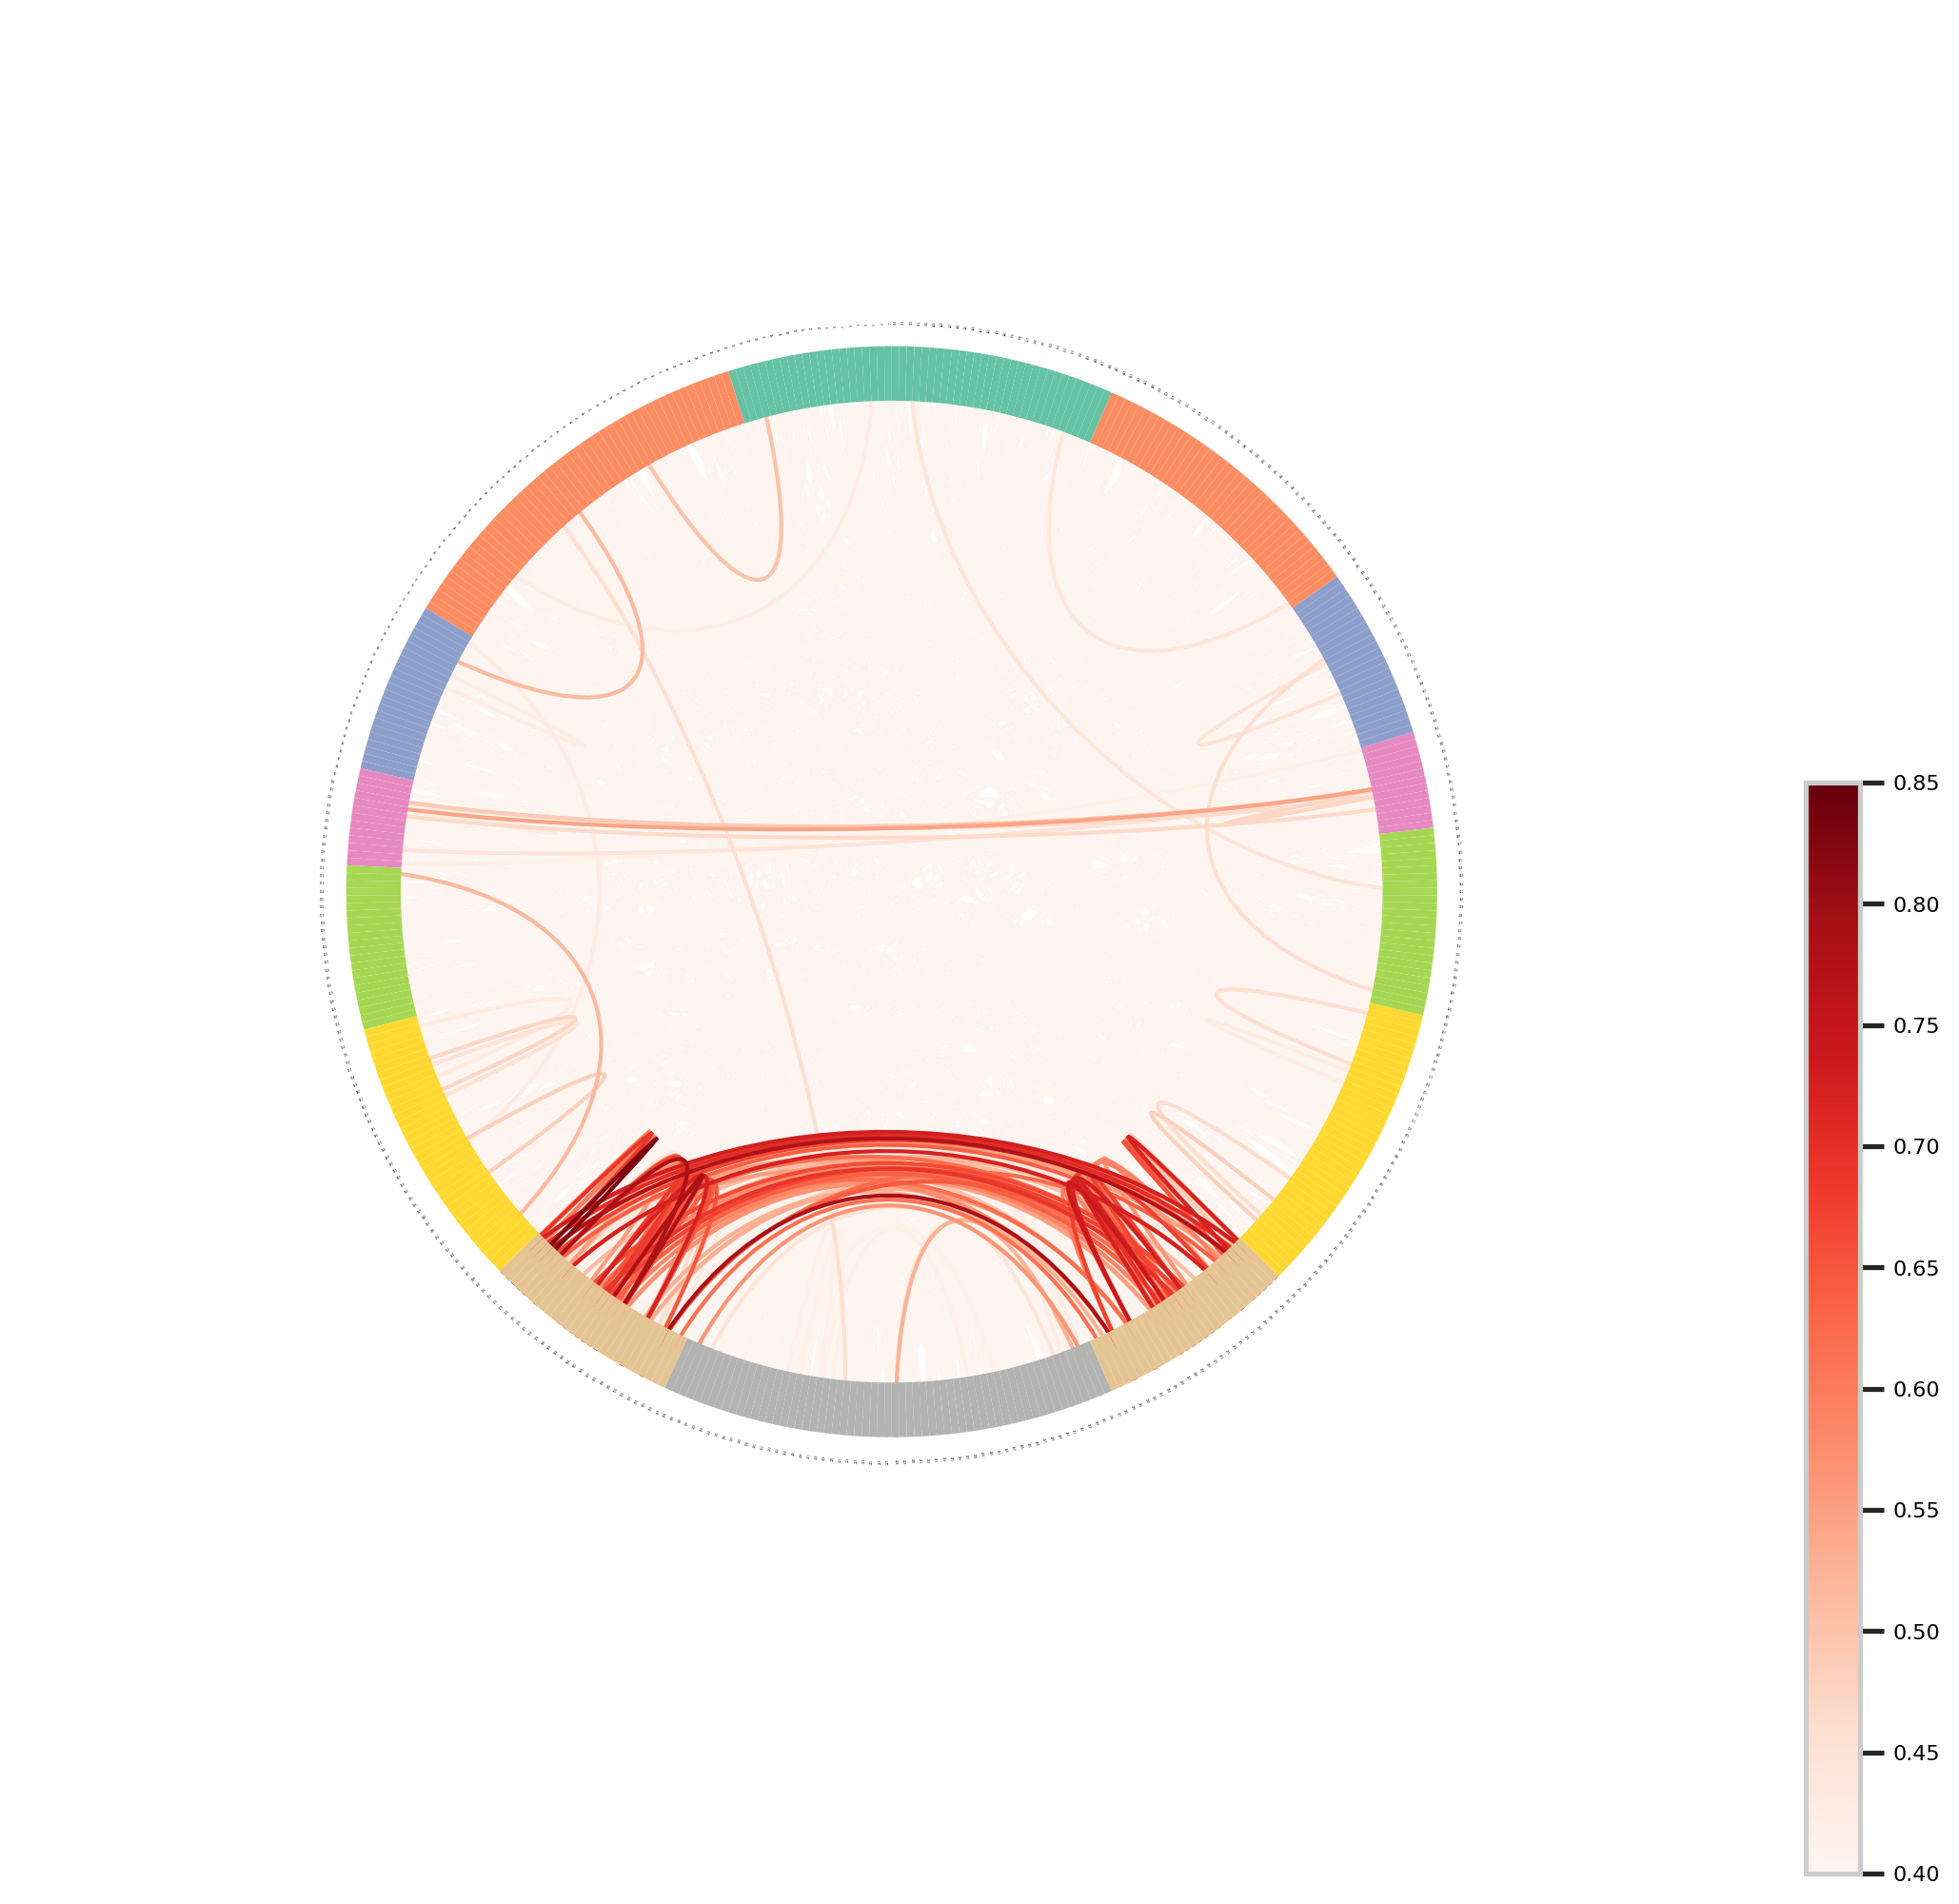

In [82]:
# --- 4. Create and Display the Plot ---
# Initialize the figure
fig, axes = plt.subplots(figsize=(12, 12), subplot_kw={"projection": "polar"})

# The plotting function from MNE
plot_connectivity_circle(
    masked_matrix**2,
    node_names=parcels[region_col].astype(str).tolist(),
    node_colors=parcels_vis[f"{network_col}_color_rgb"].tolist(),
    node_angles=node_angles,
    node_edgecolor=None,
    facecolor="white",
    textcolor="black",
    colormap="Reds",
    # n_lines=10000,
    vmin=0.4,
    vmax=0.85,
    ax=axes,
    show=False,
    # group_boundaries=['black'] * len(group_labels),
    # group_labels=group_labels,
    colorbar_pos=(-0.25, 0.1),  # Adjust colorbar position
    colorbar_size=0.5,
    node_linewidth=0,
    fontsize_names=0,
    # colorbar_label='Correlation Strength'
)

group_title = {"Q50": "Oldest Age Group", "Q1": "Youngest Age Group"}

# Set the title for the plot
# axes.set_title(group_title[f"Q{q}"], fontsize=24, pad=20)
plt.tight_layout()
# savefig_nice(
#     fig,
#     OUTPUT_DIR / f"connectivity_circle_Q{q}.png",
#     tight=True,
#     dpi=300,
# )

In [33]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------
c = {n: i for i, n in enumerate(community_id_to_rgb_map)}

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

vis_df = parcels_vis.copy()
vis_df[f"{network_col}_category"] = vis_df[network_col].astype("category").cat.codes
value_map_lh = {}  # New: separate map for left hemisphere
value_map_rh = {}  # New: separate map for right hemisphere


for i, row in vis_df.iterrows():
    label = row[region_col]
    hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

    # Apply thresholds
    value = float(row[f"{network_col}_category"]) + 1
    # value = float(vis_df.loc[i, "color_tag"]) + 1

    # Populate the correct hemisphere's value_map
    # Assuming your labels are global and you use the 'hemisphere' column to distinguish
    # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
    # then you might only need to check the label range and not the 'hemisphere' column.
    # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
    if "schaefer" in ATLAS:
        if label > int(ATLAS.split("_")[1]):
            value_map_subcortex["region"].append(label)
            value_map_subcortex["value"].append(value)
            value_map_subcortex["Hemisphere"].append(row["hemisphere"])
        else:
            if hemi_row == "L":
                value_map_lh[label] = value
            elif hemi_row == "R":
                value_map_rh[label] = value
        # Subcortex handling would go here if you were preparing for separate subcortical visualization
        # else: # This implies it's subcortical or other non-surface region
        #     value_map_subcortex["region"].append(label)
        #     value_map_subcortex["value"].append(value)
        #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

# Vectorize mapping for left and right hemispheres separately
vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation

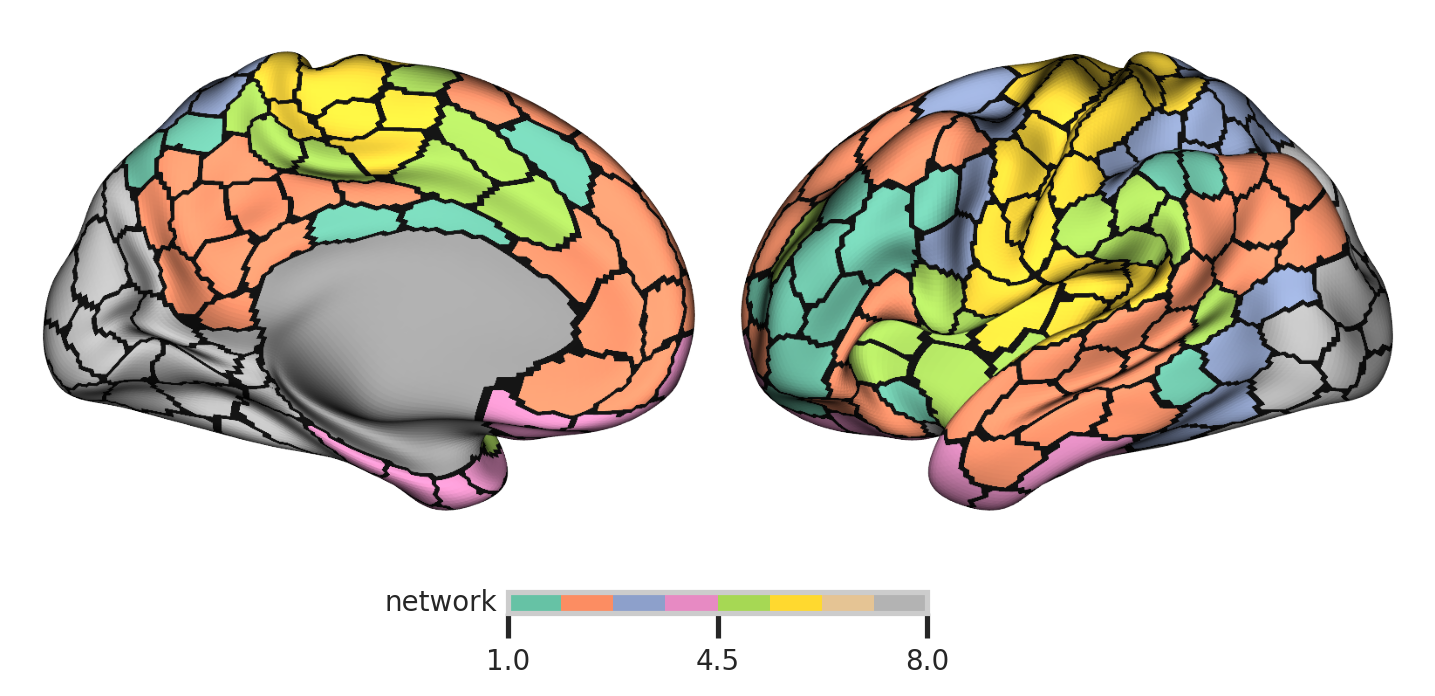

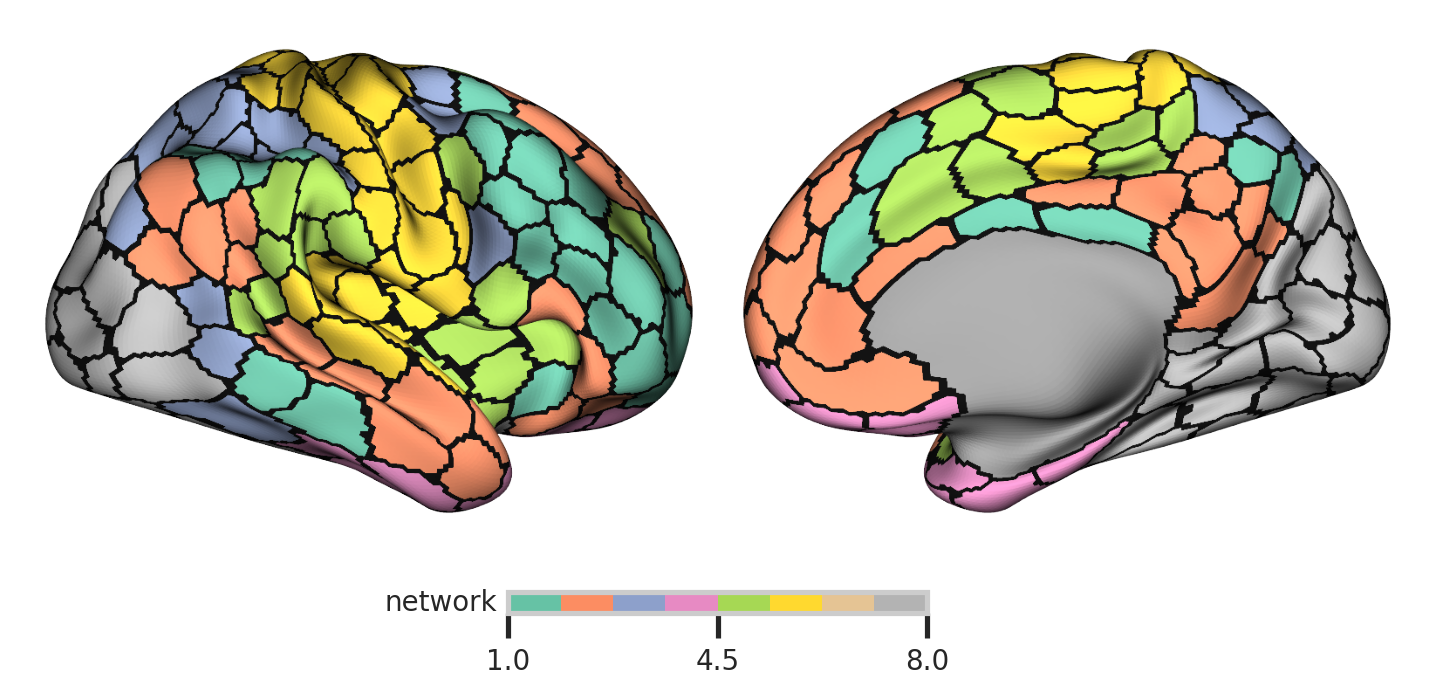

In [35]:
vmin = np.min(node_grouping) + 1  # Should be 0 if IDs start from 0
vmax = np.max(node_grouping) + 1  # Max community ID


# Corrected loop for plotting each hemisphere independently
for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
    ["left", "right"],  # The key for surfplot's dictionary
    [lh, rh],  # The surface object for the current hemisphere
    [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
    [lh_parc, rh_parc],  # The parcellation for the current hemisphere
):
    # ---------------------------------------------------------------------
    # 5.  BUILD THE PLOT
    # ---------------------------------------------------------------------
    pref_surf = {
        "surf_lh": hemi_surf_data if hemi_key == "left" else None,
        "surf_rh": hemi_surf_data if hemi_key == "right" else None,
    }

    views = ["lateral", "medial"] if hemi_key == "right" else ["medial", "lateral"]

    p = Plot(
        **pref_surf,  # Unpack the surface dictionary
        views=views,  # Show both medial and lateral for this hemi
        size=(800, 300),  # px; change as needed
        zoom=1.6,
        layout="row",  # For a single hemisphere, row is fine
        mirror_views=False,  # Set to False, as we are plotting one hemi at a time
    )

    # ---- main data layer -------------------------------------------------
    # Pass only the data for the current hemisphere
    # The dictionary now contains only one key-value pair for the current hemisphere
    p.add_layer(
        {hemi_key: mapped_data},
        cmap=cmap_communities,
        color_range=(vmin, vmax),  # Use symmetric range
        # norm=norm,  # Apply the symmetric normalization
        cbar_label="network",
        cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
    )
    # ---- outline layer ---------------------------------------------------
    p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

    fig = p.build(
        # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
    )  # Added cbar_kws for better cbar display
    # savefig_nice(
    #     fig,
    #     OUTPUT_DIR / f"{hemi_key}_yeo_7_networks.png",
    #     tight=True,
    #     dpi=300,
    # )

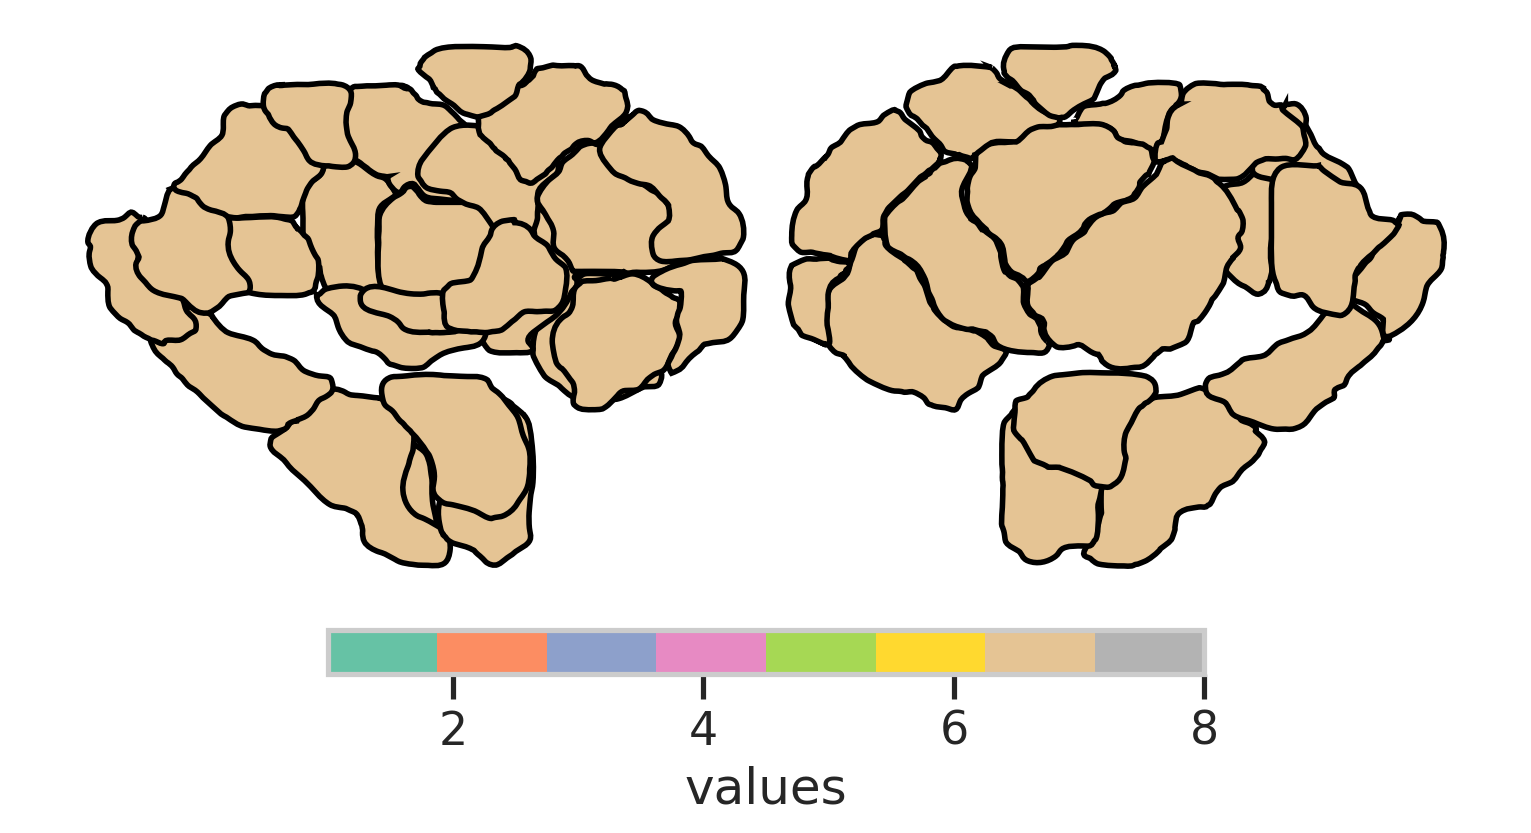

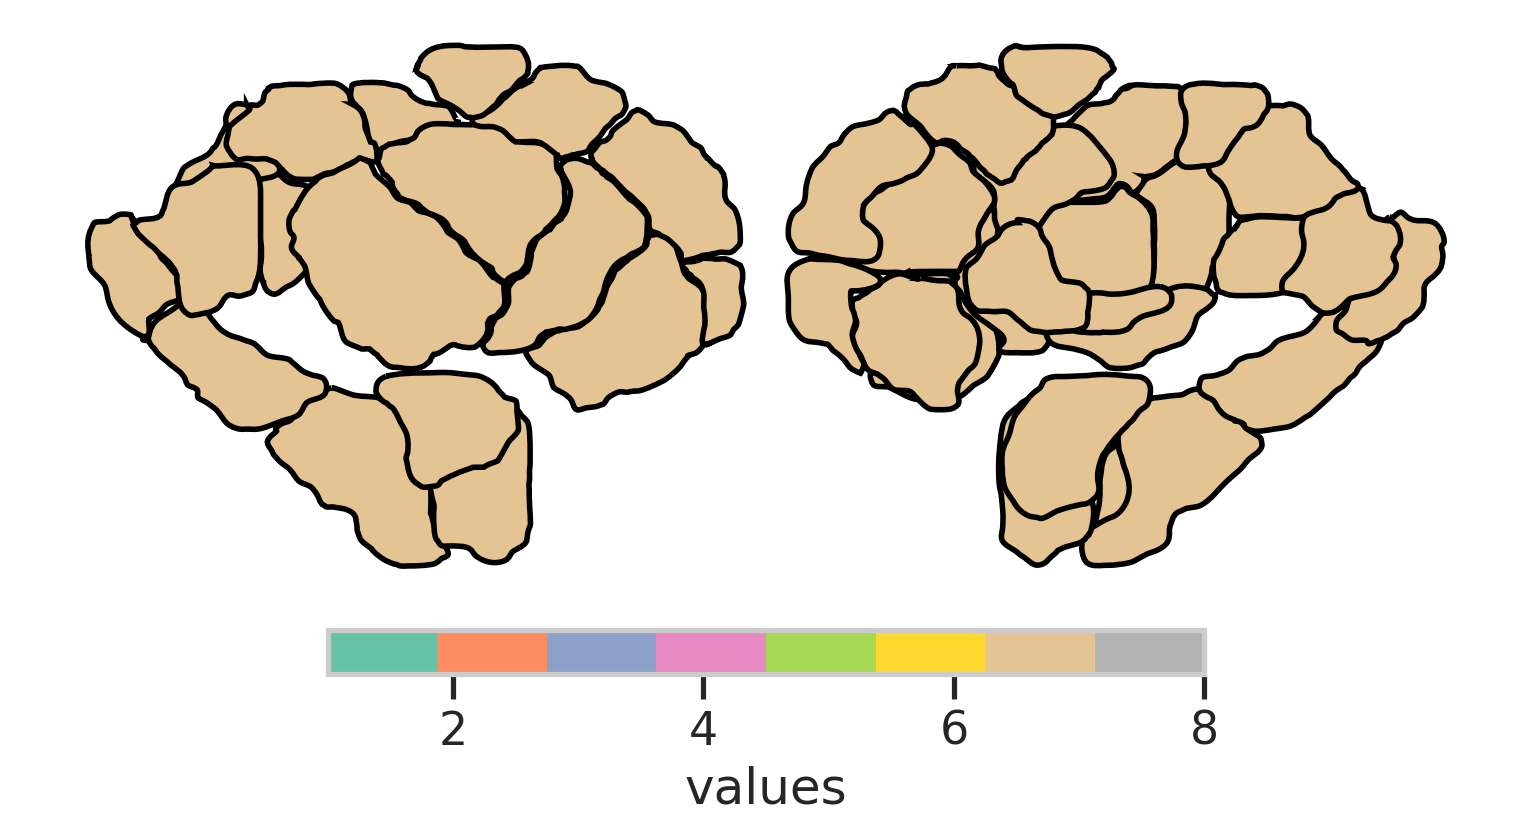

In [36]:
from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])

# subcort_df["value"] = 7
for hemi in ["L", "R"]:

    fig = plot_subcortical_data(
        subcort_df,
        atlas="Melbourne_S3",
        show_legend=True,
        hemisphere=hemi,
        cmap=cmap_communities,
        line_color="black",
        line_thickness=2,
        vmin=vmin,
        vmax=vmax,
        show_figure=False,
    )

    # save figure
    # savefig_nice(
    #     fig,
    #     OUTPUT_DIR / f"subcortical_{hemi}_yeo_subcortex.png",
    #     tight=True,
    #     dpi=300,
    # )
    # savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)